### Обучение алгоритма регрессии:
1. Предобработка
2. Разделение (train/test)
3. Выбор модели и гиперпараметров
4. Оптимизация параметров (Обучение)
5. Оценка по метрикам, проверка, переобучение
6. Кросс-валидация (CV) - для более стабильной оценки

In [189]:
from sys import displayhook

import numpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [190]:
FILE_PATH = "Housing.csv"
data = pd.read_csv(FILE_PATH)

### EDA (Exploratory Data Analysis)

In [191]:
data.head()

,rownames,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,1,42000,5850,3,1,2,yes,no,yes,no,no,1,no
1,2,38500,4000,2,1,1,yes,no,no,no,no,0,no
2,3,49500,3060,3,1,1,yes,no,no,no,no,0,no
3,4,60500,6650,3,1,2,yes,yes,no,no,no,0,no
4,5,61000,6360,2,1,1,yes,no,no,no,no,0,no


In [192]:
data.shape

(546, 13)

In [193]:
data.dtypes

rownames    int64
price       int64
lotsize     int64
bedrooms    int64
bathrms     int64
stories     int64
driveway      str
recroom       str
fullbase      str
gashw         str
airco         str
garagepl    int64
prefarea      str
dtype: object

In [194]:
data.isna().sum()

rownames    0
price       0
lotsize     0
bedrooms    0
bathrms     0
stories     0
driveway    0
recroom     0
fullbase    0
gashw       0
airco       0
garagepl    0
prefarea    0
dtype: int64

In [195]:
data.describe()

,rownames,price,lotsize,bedrooms,bathrms,stories,garagepl
count,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000,546.000000
mean,273.500000,68121.597070,5150.265568,2.965201,1.285714,1.807692,0.692308
std,157.760895,26702.670926,2168.158725,0.737388,0.502158,0.868203,0.861307
min,1.000000,25000.000000,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,137.250000,49125.000000,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,273.500000,62000.000000,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,409.750000,82000.000000,6360.000000,3.000000,2.000000,2.000000,1.000000
max,546.000000,190000.000000,16200.000000,6.000000,4.000000,4.000000,3.000000


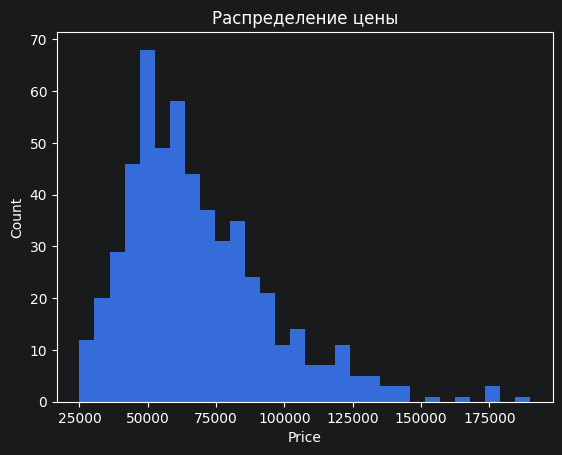

In [196]:
plt.figure()
plt.hist(data["price"], bins=30)
plt.title("Распределение цены")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

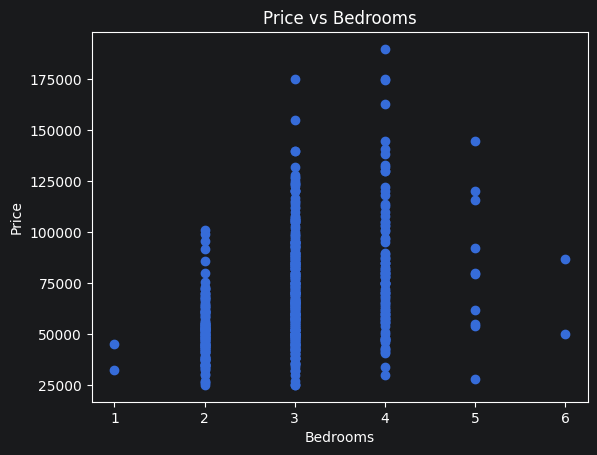

In [197]:
plt.figure()
plt.scatter(data["bedrooms"], data["price"])
plt.title("Price vs Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

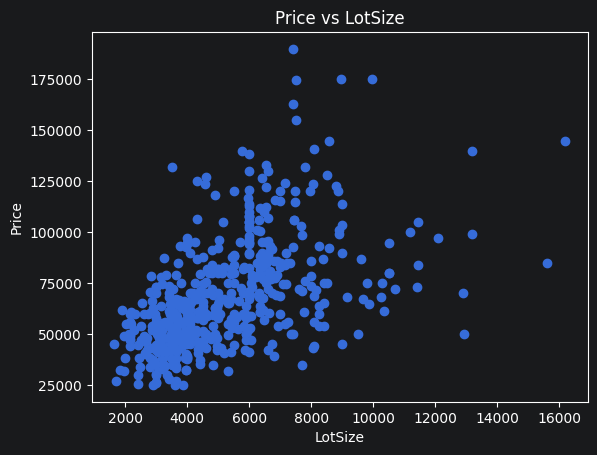

In [198]:
plt.figure()
plt.scatter(data["lotsize"], data["price"])
plt.title("Price vs LotSize")
plt.xlabel("LotSize")
plt.ylabel("Price")
plt.show()

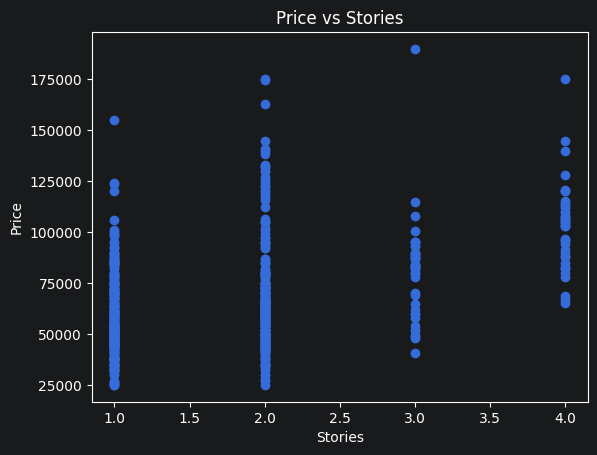

In [199]:
plt.figure()
plt.scatter(data["stories"], data["price"])
plt.title("Price vs Stories")
plt.xlabel("Stories")
plt.ylabel("Price")
plt.show()

### 1. Предобработка

In [200]:
data.head(1)

,rownames,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,1,42000,5850,3,1,2,yes,no,yes,no,no,1,no


In [201]:
target_col = "price"
numeric_cols = ["lotsize", "bedrooms","bathrms", "stories", "garagepl"]
potential_cols = ["driveway", "recroom", "fullbase", "gashw", "airco", "prefarea"]

In [202]:
categorial_cols = [c for c in potential_cols if c in data.columns]
all_used_cols = numeric_cols +categorial_cols + [target_col]
data = data[all_used_cols].copy()

In [203]:
data.head()

,lotsize,bedrooms,bathrms,stories,garagepl,driveway,recroom,fullbase,gashw,airco,prefarea,price
0,5850,3,1,2,1,yes,no,yes,no,no,no,42000
1,4000,2,1,1,0,yes,no,no,no,no,no,38500
2,3060,3,1,1,0,yes,no,no,no,no,no,49500
3,6650,3,1,2,0,yes,yes,no,no,no,no,60500
4,6360,2,1,1,0,yes,no,no,no,no,no,61000


- .factorize(series)

In [204]:
data_factorized = data.copy()
factorize_maps = {}
for col in categorial_cols:
    codes, uniques = pd.factorize(data_factorized[col])
    data_factorized[col] = codes
    factorize_maps[col] = list(uniques)
display(data_factorized.head())
factorize_maps

,lotsize,bedrooms,bathrms,stories,garagepl,driveway,recroom,fullbase,gashw,airco,prefarea,price
0,5850,3,1,2,1,0,0,0,0,0,0,42000
1,4000,2,1,1,0,0,0,1,0,0,0,38500
2,3060,3,1,1,0,0,0,1,0,0,0,49500
3,6650,3,1,2,0,0,1,1,0,0,0,60500
4,6360,2,1,1,0,0,0,1,0,0,0,61000


{'driveway': ['yes', 'no'],
 'recroom': ['no', 'yes'],
 'fullbase': ['yes', 'no'],
 'gashw': ['no', 'yes'],
 'airco': ['no', 'yes'],
 'prefarea': ['no', 'yes']}

One-hot кодирование

In [205]:
data_onehot = pd.get_dummies(data_factorized, columns=categorial_cols, drop_first=True)
display(data_onehot.head())

,lotsize,bedrooms,bathrms,stories,garagepl,price,driveway_1,recroom_1,fullbase_1,gashw_1,airco_1,prefarea_1
0,5850,3,1,2,1,42000,False,False,False,False,False,False
1,4000,2,1,1,0,38500,False,False,True,False,False,False
2,3060,3,1,1,0,49500,False,False,True,False,False,False
3,6650,3,1,2,0,60500,False,True,True,False,False,False
4,6360,2,1,1,0,61000,False,False,True,False,False,False


In [206]:
data.head()

,lotsize,bedrooms,bathrms,stories,garagepl,driveway,recroom,fullbase,gashw,airco,prefarea,price
0,5850,3,1,2,1,yes,no,yes,no,no,no,42000
1,4000,2,1,1,0,yes,no,no,no,no,no,38500
2,3060,3,1,1,0,yes,no,no,no,no,no,49500
3,6650,3,1,2,0,yes,yes,no,no,no,no,60500
4,6360,2,1,1,0,yes,no,no,no,no,no,61000


Масштабирование
1. MinMaxScaler()
2. StandardScaler()

In [207]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder

num_demo = data[numeric_cols].copy()
mms = MinMaxScaler()
std = StandardScaler()

num_mms = pd.DataFrame(mms.fit_transform(num_demo), columns=numeric_cols)
num_std = pd.DataFrame(std.fit_transform(num_demo), columns=numeric_cols)
display(num_mms)
display(num_std)

,lotsize,bedrooms,bathrms,stories,garagepl
0,0.288660,0.4,0.000000,0.333333,0.333333
1,0.161512,0.2,0.000000,0.000000,0.000000
2,0.096907,0.4,0.000000,0.000000,0.000000
3,0.343643,0.4,0.000000,0.333333,0.000000
4,0.323711,0.2,0.000000,0.000000,0.000000
...,...,...,...,...,...
541,0.216495,0.4,0.333333,1.000000,0.000000
542,0.298969,0.4,0.333333,1.000000,0.000000
543,0.298969,0.4,0.333333,1.000000,0.333333
544,0.298969,0.4,0.333333,0.333333,0.333333


,lotsize,bedrooms,bathrms,stories,garagepl
0,0.323028,0.047235,-0.569495,0.221704,0.357567
1,-0.531013,-1.310147,-0.569495,-0.931157,-0.804525
2,-0.964958,0.047235,-0.569495,-0.931157,-0.804525
3,0.692343,0.047235,-0.569495,0.221704,-0.804525
4,0.558466,-1.310147,-0.569495,-0.931157,-0.804525
...,...,...,...,...,...
541,-0.161698,0.047235,1.423737,2.527427,-0.804525
542,0.392275,0.047235,1.423737,2.527427,-0.804525
543,0.392275,0.047235,1.423737,2.527427,0.357567
544,0.392275,0.047235,1.423737,0.221704,0.357567


In [208]:
data_impute_demo = data.copy()
data_impute_demo.loc[data_impute_demo.sample(5, random_state=42).index, "lotsize"] = np.nan
data_impute_demo.loc[data_impute_demo.sample(5, random_state=42).index, "driveway"] = np.nan
print(data_impute_demo.isna().sum())

lotsize     5
bedrooms    0
bathrms     0
stories     0
garagepl    0
driveway    5
recroom     0
fullbase    0
gashw       0
airco       0
prefarea    0
price       0
dtype: int64


In [209]:
data_impute_demo

,lotsize,bedrooms,bathrms,stories,garagepl,driveway,recroom,fullbase,gashw,airco,prefarea,price
0,5850.0,3,1,2,1,yes,no,yes,no,no,no,42000
1,4000.0,2,1,1,0,yes,no,no,no,no,no,38500
2,3060.0,3,1,1,0,yes,no,no,no,no,no,49500
3,6650.0,3,1,2,0,yes,yes,no,no,no,no,60500
4,6360.0,2,1,1,0,yes,no,no,no,no,no,61000
...,...,...,...,...,...,...,...,...,...,...,...,...
541,4800.0,3,2,4,0,yes,yes,no,no,yes,no,91500
542,6000.0,3,2,4,0,yes,no,no,no,yes,no,94000
543,6000.0,3,2,4,1,yes,yes,no,no,yes,no,103000
544,6000.0,3,2,2,1,yes,yes,no,no,yes,no,105000


In [210]:
from sklearn.impute import SimpleImputer
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")
data_impute_demo[numeric_cols] = num_imputer.fit_transform(data_impute_demo[numeric_cols])
data_impute_demo[categorial_cols] = cat_imputer.fit_transform(data_impute_demo[categorial_cols])
displayhook(data_impute_demo.isna().sum())

lotsize     0
bedrooms    0
bathrms     0
stories     0
garagepl    0
driveway    0
recroom     0
fullbase    0
gashw       0
airco       0
prefarea    0
price       0
dtype: int64

Feature Engineering (создание новых признаков)

In [211]:
data_fe = data.copy()
data_fe["rooms_total"] = data_fe["bedrooms"] + data_fe["bathrms"]
data_fe["lotsize_per_room"] = data_fe["lotsize"] / np.where( data_fe["rooms_total"] > 0, data_fe["rooms_total"], 1)
data_fe[["lotsize", "bedrooms", "bathrms", "rooms_total", "lotsize_per_room"]].head()

,lotsize,bedrooms,bathrms,rooms_total,lotsize_per_room
0,5850,3,1,4,1462.500000
1,4000,2,1,3,1333.333333
2,3060,3,1,4,765.000000
3,6650,3,1,4,1662.500000
4,6360,2,1,3,2120.000000


Процесс обучения

In [212]:
X = data_fe.drop(columns=[target_col])
y = data_fe[target_col]
# 2. Разделение (train/test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_features = numeric_cols + ["rooms_total", "lotsize_per_room"]
cat_features = categorial_cols

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

linreg_model = Pipeline(steps=[
    ("preprocessor", preprocess),
    ("model", LinearRegression())
])

linreg_model.fit(X_train, y_train)
y_pred = linreg_model.predict(X_test)

# Метрики (MAE, MSE, RMSE, R2_score)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
(mae, mse, rmse, r2)


(11228.976889736126,
 252980638.6957399,
 np.float64(15905.365091557625),
 0.6213292080382551)

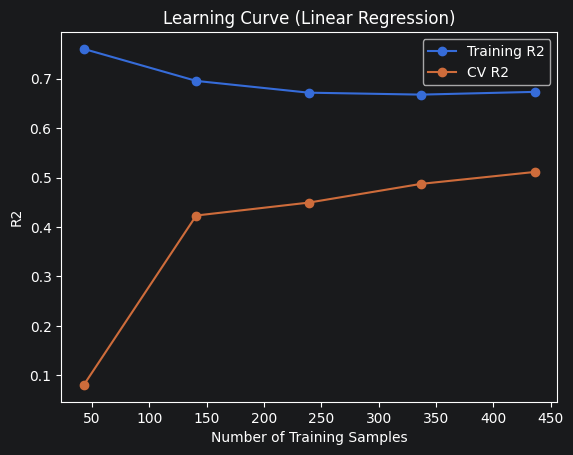

In [213]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(linreg_model, X, y, cv=5, scoring='r2', train_sizes=np.linspace(.1, 1.0, 5), n_jobs=None, shuffle=True, random_state=42)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker='o', label='Training R2')
plt.plot(train_sizes, test_mean, 'o-', label='CV R2')
plt.title('Learning Curve (Linear Regression)')
plt.xlabel('Number of Training Samples')
plt.ylabel('R2')
plt.legend(loc='best')
plt.show()